In [4]:
print("Hotel Booking Demand - Machine Learning Analysis")

Hotel Booking Demand - Machine Learning Analysis


In [5]:
import pandas as pd
import numpy as np

# Load the Hotel Booking Demand dataset
df = pd.read_csv("../Dataset/hotel_bookings.csv")

# Display the first 5 rows
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [6]:
# Check the number of rows and columns
df.shape

(119390, 32)

In [7]:
# Display all column names
df.columns.tolist()

['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'agent',
 'company',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'reservation_status',
 'reservation_status_date']

In [8]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [9]:
# Calculate missing values for each column
missing_values = df.isnull().sum()

# Display only columns that contain missing values
missing_values[missing_values > 0]

children         4
country        488
agent        16340
company     112593
dtype: int64

In [10]:
# Create a missing-value summary
missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

# Display only columns with missing values
missing_summary = missing_summary[
    missing_summary['Missing Values'] > 0
].sort_values('Missing Percentage', ascending=False)

missing_summary

,Missing Values,Missing Percentage
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


In [11]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 31994


In [12]:
# Check the distribution of the target variable
target_counts = df['is_canceled'].value_counts()

print("Booking cancellation distribution:")
print(target_counts)

Booking cancellation distribution:
is_canceled
0    75166
1    44224
Name: count, dtype: int64


In [13]:
# Calculate the percentage distribution
target_percentage = (
    df['is_canceled']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Booking cancellation percentage:")
print(target_percentage)

Booking cancellation percentage:
is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64


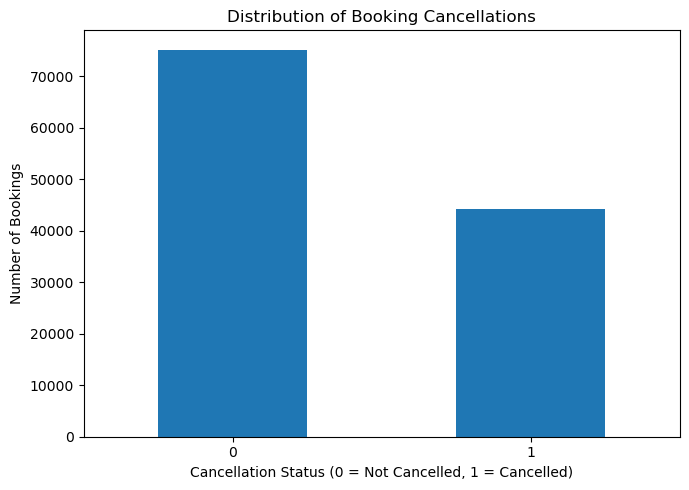

In [14]:
import matplotlib.pyplot as plt

# Plot the distribution of booking cancellations
df['is_canceled'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title('Distribution of Booking Cancellations')
plt.xlabel('Cancellation Status (0 = Not Cancelled, 1 = Cancelled)')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
# Display summary statistics for numerical variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [16]:
# Check for unusual guest-count values
guest_columns = ['adults', 'children', 'babies']

for column in guest_columns:
    print(f"\n{column.upper()}")
    print(df[column].value_counts().sort_index())


ADULTS
adults
0       403
1     23027
2     89680
3      6202
4        62
5         2
6         1
10        1
20        2
26        5
27        2
40        1
50        1
55        1
Name: count, dtype: int64

CHILDREN
children
0.0     110796
1.0       4861
2.0       3652
3.0         76
10.0         1
Name: count, dtype: int64

BABIES
babies
0     118473
1        900
2         15
9          1
10         1
Name: count, dtype: int64


In [17]:
# Investigate bookings with zero adults
zero_adults = df[df['adults'] == 0]

zero_adults[['adults', 'children', 'babies', 'is_canceled']].value_counts()

adults  children  babies  is_canceled
0       0.0       0       0              155
        2.0       0       0              125
                          1               80
        0.0       0       1               25
        3.0       0       0                8
        1.0       0       0                4
        3.0       0       1                3
        2.0       1       0                2
                          1                1
Name: count, dtype: int64

In [18]:
# Display bookings with unusually high numbers of adults
high_adults = df[df['adults'] >= 10]

high_adults[['adults', 'children', 'babies', 'hotel', 'is_canceled']]

,adults,children,babies,hotel,is_canceled
1539,40,0.0,0,Resort Hotel,1
1587,26,0.0,0,Resort Hotel,1
1643,50,0.0,0,Resort Hotel,1
1752,26,0.0,0,Resort Hotel,1
1884,26,0.0,0,Resort Hotel,1
1917,27,0.0,0,Resort Hotel,1
1962,27,0.0,0,Resort Hotel,1
2003,26,0.0,0,Resort Hotel,1
2164,26,0.0,0,Resort Hotel,1
2173,55,0.0,0,Resort Hotel,1


In [19]:
# Check the minimum and maximum ADR values
print("Minimum ADR:", df['adr'].min())
print("Maximum ADR:", df['adr'].max())

# Check bookings with zero or negative ADR
print("\nBookings with ADR <= 0:")
print((df['adr'] <= 0).sum())

Minimum ADR: -6.38
Maximum ADR: 5400.0

Bookings with ADR <= 0:
1960


In [20]:
# Investigate bookings with zero or negative ADR
zero_negative_adr = df[df['adr'] <= 0]

zero_negative_adr[
    ['hotel', 'is_canceled', 'lead_time', 'adr',
     'deposit_type', 'market_segment', 'customer_type']
].head(20)


,hotel,is_canceled,lead_time,adr,deposit_type,market_segment,customer_type
0,Resort Hotel,0,342,0.0,No Deposit,Direct,Transient
1,Resort Hotel,0,737,0.0,No Deposit,Direct,Transient
125,Resort Hotel,0,32,0.0,No Deposit,Complementary,Transient
167,Resort Hotel,0,111,0.0,No Deposit,Online TA,Transient
168,Resort Hotel,0,0,0.0,No Deposit,Direct,Transient
196,Resort Hotel,0,8,0.0,No Deposit,Direct,Transient
197,Resort Hotel,0,8,0.0,No Deposit,Online TA,Transient
421,Resort Hotel,1,57,0.0,No Deposit,Groups,Transient-Party
428,Resort Hotel,0,57,0.0,No Deposit,Groups,Transient-Party
459,Resort Hotel,0,6,0.0,No Deposit,Online TA,Transient


In [21]:
# Investigate negative ADR records
negative_adr = df[df['adr'] < 0]

negative_adr[
    ['hotel', 'is_canceled', 'lead_time', 'adr',
     'deposit_type', 'market_segment', 'customer_type']
]

,hotel,is_canceled,lead_time,adr,deposit_type,market_segment,customer_type
14969,Resort Hotel,0,195,-6.38,No Deposit,Groups,Transient-Party


In [22]:
# Check unique categories in important categorical variables
categorical_columns = [
    'hotel',
    'meal',
    'market_segment',
    'deposit_type',
    'customer_type'
]

for column in categorical_columns:
    print(f"\n{column.upper()}")
    print(df[column].value_counts())


HOTEL
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

MEAL
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64

MARKET_SEGMENT
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

DEPOSIT_TYPE
deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64

CUSTOMER_TYPE
customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64


In [23]:
# Check the number of unique values in selected categorical variables
high_cardinality_columns = [
    'country',
    'agent',
    'company',
    'reserved_room_type',
    'assigned_room_type'
]

for column in high_cardinality_columns:
    print(f"{column}: {df[column].nunique()} unique values")

country: 177 unique values
agent: 333 unique values
company: 352 unique values
reserved_room_type: 10 unique values
assigned_room_type: 12 unique values


In [24]:
# Check for leading/trailing whitespace in categorical values

categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    whitespace_count = df[column].dropna().astype(str).str.strip().ne(
        df[column].dropna().astype(str)
    ).sum()

    if whitespace_count > 0:
        print(f"{column}: {whitespace_count} values with extra whitespace")

In [25]:
# Calculate correlations between numerical variables
numeric_df = df.select_dtypes(include=['int64', 'float64'])

correlation_matrix = numeric_df.corr()

correlation_matrix.round(2)

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
is_canceled,1.00,0.29,0.02,0.01,-0.01,-0.00,0.02,0.06,0.01,-0.03,-0.08,0.11,-0.06,-0.14,-0.08,-0.02,0.05,0.05,-0.20,-0.23
lead_time,0.29,1.00,0.04,0.13,0.00,0.09,0.17,0.12,-0.04,-0.02,-0.12,0.09,-0.07,0.00,-0.07,0.15,0.17,-0.06,-0.12,-0.10
arrival_date_year,0.02,0.04,1.00,-0.54,-0.00,0.02,0.03,0.03,0.05,-0.01,0.01,-0.12,0.03,0.03,0.06,0.26,-0.06,0.20,-0.01,0.11
arrival_date_week_number,0.01,0.13,-0.54,1.00,0.07,0.02,0.02,0.03,0.01,0.01,-0.03,0.04,-0.02,0.01,-0.03,-0.08,0.02,0.08,0.00,0.03
arrival_date_day_of_month,-0.01,0.00,-0.00,0.07,1.00,-0.02,-0.03,-0.00,0.01,-0.00,-0.01,-0.03,-0.00,0.01,0.00,0.04,0.02,0.03,0.01,0.00
stays_in_weekend_nights,-0.00,0.09,0.02,0.02,-0.02,1.00,0.50,0.09,0.05,0.02,-0.09,-0.01,-0.04,0.06,0.14,0.07,-0.05,0.05,-0.02,0.07
stays_in_week_nights,0.02,0.17,0.03,0.02,-0.03,0.50,1.00,0.09,0.04,0.02,-0.10,-0.01,-0.05,0.10,0.18,0.18,-0.00,0.07,-0.02,0.07
adults,0.06,0.12,0.03,0.03,-0.00,0.09,0.09,1.00,0.03,0.02,-0.15,-0.01,-0.11,-0.05,-0.04,0.21,-0.01,0.23,0.01,0.12
children,0.01,-0.04,0.05,0.01,0.01,0.05,0.04,0.03,1.00,0.02,-0.03,-0.02,-0.02,0.05,0.04,0.03,-0.03,0.32,0.06,0.08
babies,-0.03,-0.02,-0.01,0.01,-0.00,0.02,0.02,0.02,0.02,1.00,-0.01,-0.01,-0.01,0.08,0.04,0.02,-0.01,0.03,0.04,0.10


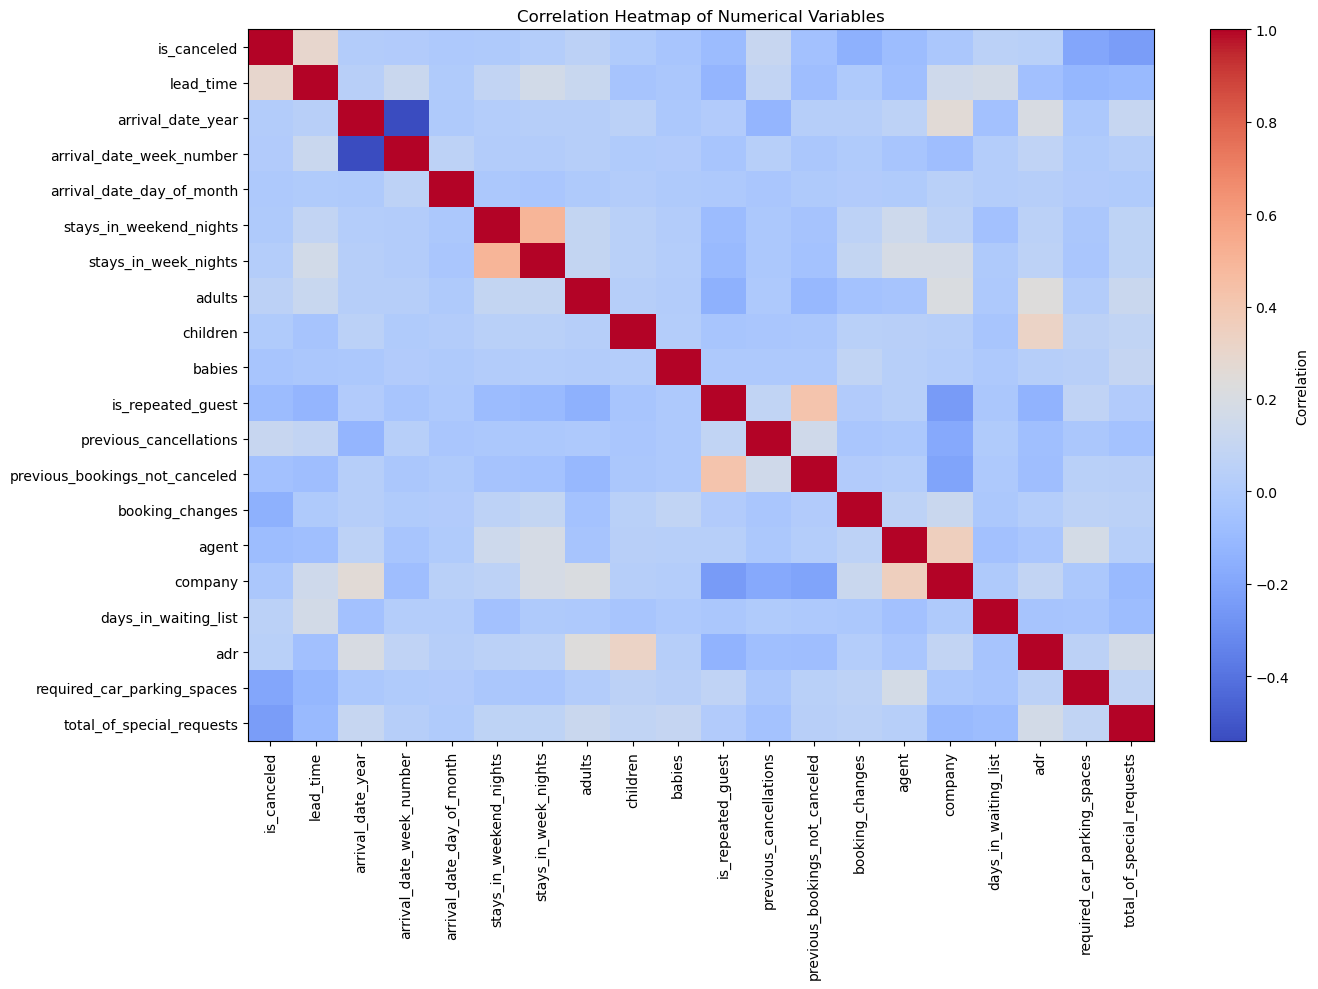

In [26]:
import matplotlib.pyplot as plt

# Create correlation heatmap
plt.figure(figsize=(14, 10))

plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Correlation')

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

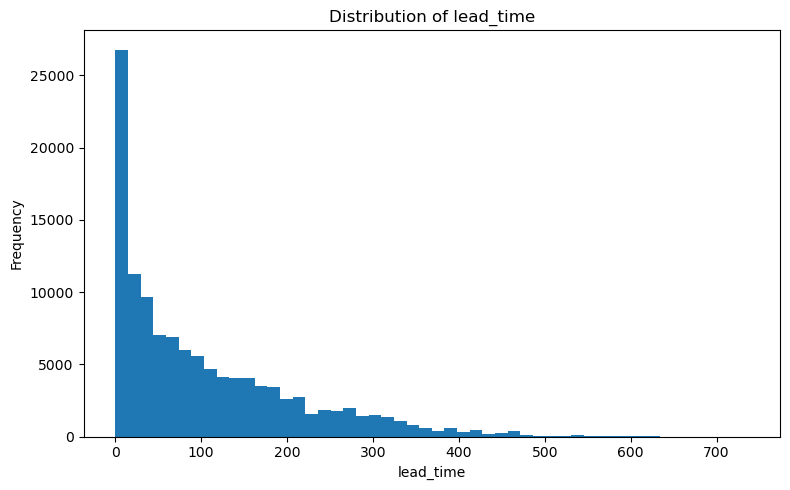

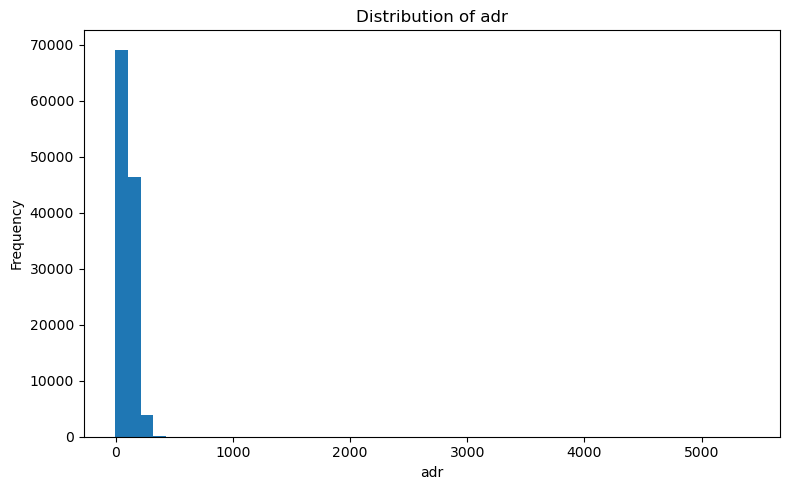

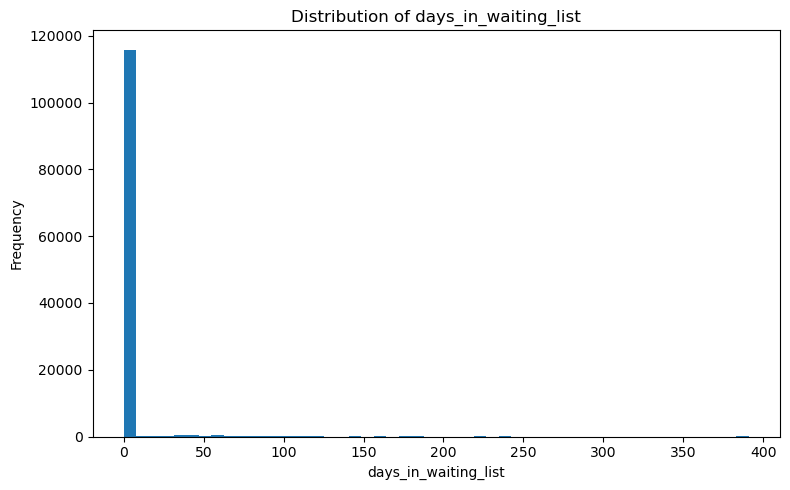

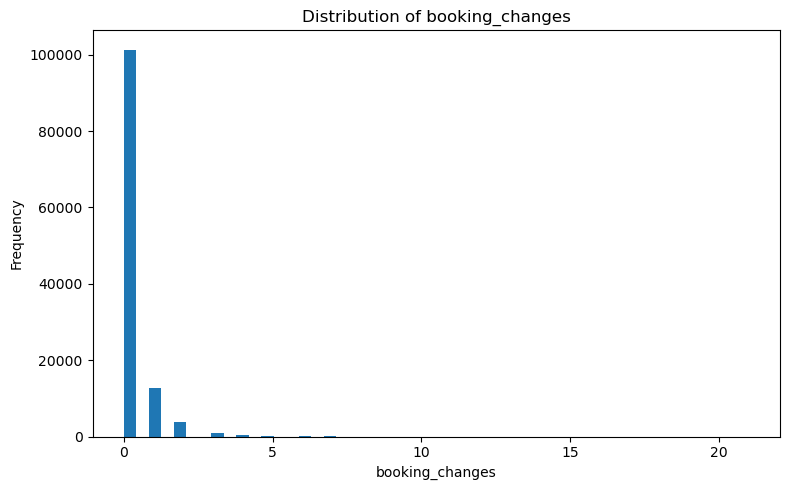

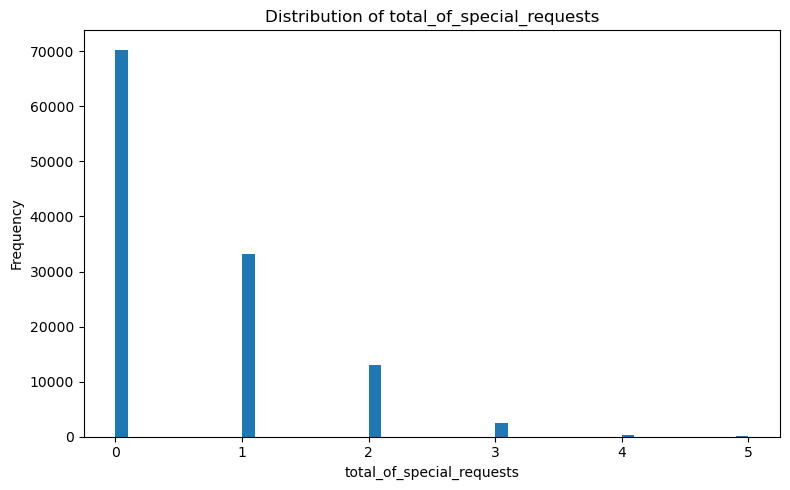

In [27]:
# Plot distributions of key numerical variables

key_numeric = [
    'lead_time',
    'adr',
    'days_in_waiting_list',
    'booking_changes',
    'total_of_special_requests'
]

for column in key_numeric:
    plt.figure(figsize=(8, 5))
    plt.hist(df[column].dropna(), bins=50)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

In [28]:
# Detect potential outliers using the IQR method

outlier_columns = [
    'lead_time',
    'adr',
    'days_in_waiting_list',
    'booking_changes',
    'total_of_special_requests'
]

for column in outlier_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"\n{column}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Potential outliers: {len(outliers)}")


lead_time
Lower bound: -195.00
Upper bound: 373.00
Potential outliers: 3005

adr
Lower bound: -15.77
Upper bound: 211.06
Potential outliers: 3793

days_in_waiting_list
Lower bound: 0.00
Upper bound: 0.00
Potential outliers: 3698

booking_changes
Lower bound: 0.00
Upper bound: 0.00
Potential outliers: 18076

total_of_special_requests
Lower bound: -1.50
Upper bound: 2.50
Potential outliers: 2877


In [29]:
# Detect potential outliers using the IQR method

outlier_columns = [
    'lead_time',
    'adr',
    'days_in_waiting_list',
    'booking_changes',
    'total_of_special_requests'
]

for column in outlier_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"\n{column}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Potential outliers: {len(outliers)}")


lead_time
Lower bound: -195.00
Upper bound: 373.00
Potential outliers: 3005

adr
Lower bound: -15.77
Upper bound: 211.06
Potential outliers: 3793

days_in_waiting_list
Lower bound: 0.00
Upper bound: 0.00
Potential outliers: 3698

booking_changes
Lower bound: 0.00
Upper bound: 0.00
Potential outliers: 18076

total_of_special_requests
Lower bound: -1.50
Upper bound: 2.50
Potential outliers: 2877


In [30]:
# Check for unusual stay-length combinations

stay_check = df[
    (df['stays_in_weekend_nights'] < 0) |
    (df['stays_in_week_nights'] < 0)
]

print("Rows with negative stay values:", len(stay_check))

print("\nStay length summary:")
print(df[['stays_in_weekend_nights', 'stays_in_week_nights']].describe())

Rows with negative stay values: 0

Stay length summary:
       stays_in_weekend_nights  stays_in_week_nights
count            119390.000000         119390.000000
mean                  0.927599              2.500302
std                   0.998613              1.908286
min                   0.000000              0.000000
25%                   0.000000              1.000000
50%                   1.000000              2.000000
75%                   2.000000              3.000000
max                  19.000000             50.000000


In [31]:
# Check for bookings with no guests recorded

no_guest_bookings = df[
    (df['adults'] == 0) &
    (df['children'].fillna(0) == 0) &
    (df['babies'] == 0)
]

print("Bookings with no guests recorded:", len(no_guest_bookings))

print("\nExamples:")
print(
    no_guest_bookings[
        ['hotel', 'adults', 'children', 'babies', 'is_canceled']
    ].head(10)
)

Bookings with no guests recorded: 180

Examples:
              hotel  adults  children  babies  is_canceled
2224   Resort Hotel       0       0.0       0            0
2409   Resort Hotel       0       0.0       0            0
3181   Resort Hotel       0       0.0       0            0
3684   Resort Hotel       0       0.0       0            0
3708   Resort Hotel       0       0.0       0            0
4127   Resort Hotel       0       0.0       0            1
9376   Resort Hotel       0       0.0       0            1
31765  Resort Hotel       0       0.0       0            0
32029  Resort Hotel       0       0.0       0            0
32827  Resort Hotel       0       0.0       0            0


In [32]:
# Check date-related values for consistency

print("Arrival year values:")
print(df['arrival_date_year'].value_counts().sort_index())

print("\nArrival month values:")
print(df['arrival_date_month'].value_counts())

print("\nWeek number range:")
print(df['arrival_date_week_number'].min(), "to", df['arrival_date_week_number'].max())

print("\nDay of month range:")
print(df['arrival_date_day_of_month'].min(), "to", df['arrival_date_day_of_month'].max())

Arrival year values:
arrival_date_year
2015    21996
2016    56707
2017    40687
Name: count, dtype: int64

Arrival month values:
arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929
Name: count, dtype: int64

Week number range:
1 to 53

Day of month range:
1 to 31


In [33]:
# Examine reservation status in relation to cancellation

print("Reservation status counts:")
print(df['reservation_status'].value_counts())

print("\nCancellation rate by reservation status:")
print(
    pd.crosstab(
        df['reservation_status'],
        df['is_canceled'],
        normalize='index'
    ).round(3)
)

Reservation status counts:
reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64

Cancellation rate by reservation status:
is_canceled           0    1
reservation_status          
Canceled            0.0  1.0
Check-Out           1.0  0.0
No-Show             0.0  1.0


In [34]:
# Check reservation status date information

print("Reservation status date data type:")
print(df['reservation_status_date'].dtype)

print("\nNumber of unique reservation status dates:")
print(df['reservation_status_date'].nunique())

print("\nSample reservation status dates:")
print(df['reservation_status_date'].head(10))

Reservation status date data type:
object

Number of unique reservation status dates:
926

Sample reservation status dates:
0    2015-07-01
1    2015-07-01
2    2015-07-02
3    2015-07-02
4    2015-07-03
5    2015-07-03
6    2015-07-03
7    2015-07-03
8    2015-05-06
9    2015-04-22
Name: reservation_status_date, dtype: object


In [35]:
# Compare reservation status with cancellation outcome

status_cancellation = pd.crosstab(
    df['reservation_status'],
    df['is_canceled']
)

print(status_cancellation)


is_canceled             0      1
reservation_status              
Canceled                0  43017
Check-Out           75166      0
No-Show                 0   1207


In [36]:
# Compare reservation status with cancellation outcome

status_cancellation = pd.crosstab(
    df['reservation_status'],
    df['is_canceled']
)

print(status_cancellation)

is_canceled             0      1
reservation_status              
Canceled                0  43017
Check-Out           75166      0
No-Show                 0   1207


In [37]:
# Check duplicate rows and their cancellation outcomes

duplicate_rows = df[df.duplicated(keep=False)]

print("Total duplicate rows:", len(duplicate_rows))

print("\nCancellation distribution among duplicate rows:")
print(duplicate_rows['is_canceled'].value_counts())

Total duplicate rows: 40165

Cancellation distribution among duplicate rows:
is_canceled
1    23451
0    16714
Name: count, dtype: int64


In [38]:
# Compare missing values between cancelled and non-cancelled bookings

missing_by_target = df.groupby('is_canceled').apply(
    lambda x: x.isnull().sum()
)

print(missing_by_target[['children', 'country', 'agent', 'company']])

             children  country  agent  company
is_canceled                                   
0                   0      421  12310    69560
1                   4       67   4030    43033


In [39]:
# Check unique values in important categorical variables

categorical_check = [
    'hotel',
    'meal',
    'market_segment',
    'distribution_channel',
    'deposit_type',
    'customer_type'
]

for column in categorical_check:
    print(f"\n{column}")
    print(df[column].value_counts(dropna=False))


hotel
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

meal
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64

market_segment
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

distribution_channel
distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64

deposit_type
deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64

customer_type
customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64


In [40]:
# Check numerical variables for negative values

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

for column in numeric_columns:
    negative_count = (df[column] < 0).sum()

    if negative_count > 0:
        print(f"{column}: {negative_count} negative values")

adr: 1 negative values


In [41]:
# Compare key numerical variables by cancellation outcome

key_variables = [
    'lead_time',
    'adr',
    'booking_changes',
    'days_in_waiting_list',
    'total_of_special_requests'
]

target_comparison = df.groupby('is_canceled')[key_variables].mean().round(2)

print(target_comparison)

             lead_time     adr  booking_changes  days_in_waiting_list  \
is_canceled                                                             
0                79.98   99.99             0.29                  1.59   
1               144.85  104.96             0.10                  3.56   

             total_of_special_requests  
is_canceled                             
0                                 0.71  
1                                 0.33  


In [42]:
# Cancellation rate by important categorical variables

categorical_variables = [
    'hotel',
    'market_segment',
    'deposit_type',
    'customer_type'
]

for column in categorical_variables:
    print(f"\nCancellation rate by {column}:")
    
    cancellation_rate = (
        df.groupby(column)['is_canceled']
        .mean()
        .sort_values(ascending=False)
        .round(3)
    )
    
    print(cancellation_rate)


Cancellation rate by hotel:
hotel
City Hotel      0.417
Resort Hotel    0.278
Name: is_canceled, dtype: float64

Cancellation rate by market_segment:
market_segment
Undefined        1.000
Groups           0.611
Online TA        0.367
Offline TA/TO    0.343
Aviation         0.219
Corporate        0.187
Direct           0.153
Complementary    0.131
Name: is_canceled, dtype: float64

Cancellation rate by deposit_type:
deposit_type
Non Refund    0.994
No Deposit    0.284
Refundable    0.222
Name: is_canceled, dtype: float64

Cancellation rate by customer_type:
customer_type
Transient          0.407
Contract           0.310
Transient-Party    0.254
Group              0.102
Name: is_canceled, dtype: float64


In [43]:
# Create lead-time groups and compare cancellation rates

df['lead_time_group'] = pd.cut(
    df['lead_time'],
    bins=[-1, 30, 90, 180, 365, float('inf')],
    labels=['0-30', '31-90', '91-180', '181-365', '366+']
)

lead_time_cancellation = (
    df.groupby('lead_time_group', observed=False)['is_canceled']
    .mean()
    .round(3)
)

print(lead_time_cancellation)

lead_time_group
0-30       0.186
31-90      0.377
91-180     0.447
181-365    0.555
366+       0.677
Name: is_canceled, dtype: float64


In [44]:
# Check for columns with only one unique value

constant_columns = []

for column in df.columns:
    if df[column].nunique(dropna=False) <= 1:
        constant_columns.append(column)

print("Constant columns:")
print(constant_columns)

Constant columns:
[]


In [45]:
# Cancellation rate for each hotel type

hotel_cancellation = (
    df.groupby('hotel')['is_canceled']
    .mean()
    .round(3)
)

print("Cancellation rate by hotel:")
print(hotel_cancellation)

Cancellation rate by hotel:
hotel
City Hotel      0.417
Resort Hotel    0.278
Name: is_canceled, dtype: float64


In [46]:
# Median values by cancellation outcome

median_comparison = df.groupby('is_canceled')[
    ['lead_time', 'adr', 'booking_changes',
     'days_in_waiting_list', 'total_of_special_requests']
].median().round(2)

print("Median comparison:")
print(median_comparison)

Median comparison:
             lead_time   adr  booking_changes  days_in_waiting_list  \
is_canceled                                                           
0                 45.0  92.5              0.0                   0.0   
1                113.0  96.2              0.0                   0.0   

             total_of_special_requests  
is_canceled                             
0                                  1.0  
1                                  0.0  


In [47]:
# Calculate missing-value percentages

missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

print("Missing-value percentages:")
print(missing_percentage[missing_percentage > 0].round(2))

Missing-value percentages:
company     94.31
agent       13.69
country      0.41
children     0.00
dtype: float64


In [48]:
# Check skewness of important numerical variables

skewness = df[
    ['lead_time',
     'adr',
     'days_in_waiting_list',
     'booking_changes',
     'total_of_special_requests']
].skew().sort_values(ascending=False)

print("Skewness of key numerical variables:")
print(skewness.round(2))

Skewness of key numerical variables:
days_in_waiting_list         11.94
adr                          10.53
booking_changes               6.00
total_of_special_requests     1.35
lead_time                     1.35
dtype: float64


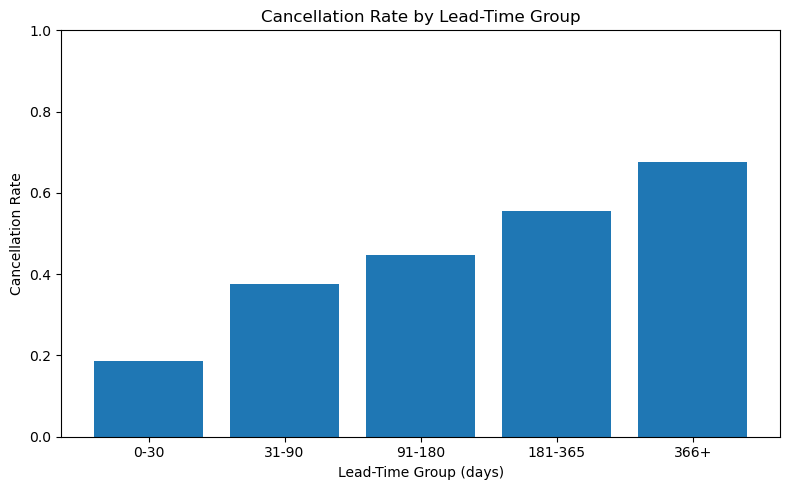

In [49]:
# Visualise cancellation rate by lead-time group

lead_time_rate = (
    df.groupby('lead_time_group', observed=False)['is_canceled']
    .mean()
)

plt.figure(figsize=(8, 5))
plt.bar(
    lead_time_rate.index.astype(str),
    lead_time_rate.values
)

plt.title('Cancellation Rate by Lead-Time Group')
plt.xlabel('Lead-Time Group (days)')
plt.ylabel('Cancellation Rate')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [50]:
# Final summary of major data-quality issues

print("FINAL DATA QUALITY SUMMARY")
print("-" * 40)

print("Dataset size:", df.shape)

print("\nDuplicate rows:", df.duplicated().sum())

print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nTarget distribution:")
print(df['is_canceled'].value_counts())

print("\nNegative numerical values:")
for column in df.select_dtypes(include=['int64', 'float64']).columns:
    count = (df[column] < 0).sum()
    if count > 0:
        print(f"{column}: {count}")

FINAL DATA QUALITY SUMMARY
----------------------------------------
Dataset size: (119390, 33)

Duplicate rows: 31994

Missing values:
children         4
country        488
agent        16340
company     112593
dtype: int64

Target distribution:
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Negative numerical values:
adr: 1


In [51]:
# Create a separate copy for preprocessing

df_clean = df.copy()

print("Original dataset shape:", df.shape)
print("Preprocessing dataset shape:", df_clean.shape)

Original dataset shape: (119390, 33)
Preprocessing dataset shape: (119390, 33)


In [52]:
# Remove temporary EDA column

df_clean = df_clean.drop(columns=['lead_time_group'])

print("Dataset shape after removing temporary column:", df_clean.shape)

Dataset shape after removing temporary column: (119390, 32)


In [53]:
# Remove variables that can cause target leakage

leakage_columns = [
    'reservation_status',
    'reservation_status_date'
]

df_clean = df_clean.drop(columns=leakage_columns)

print("Removed leakage columns:", leakage_columns)
print("Dataset shape:", df_clean.shape)

Removed leakage columns: ['reservation_status', 'reservation_status_date']
Dataset shape: (119390, 30)


In [54]:
# Display remaining columns after leakage removal

print("Remaining columns:")
for i, column in enumerate(df_clean.columns, start=1):
    print(f"{i}. {column}")

Remaining columns:
1. hotel
2. is_canceled
3. lead_time
4. arrival_date_year
5. arrival_date_month
6. arrival_date_week_number
7. arrival_date_day_of_month
8. stays_in_weekend_nights
9. stays_in_week_nights
10. adults
11. children
12. babies
13. meal
14. country
15. market_segment
16. distribution_channel
17. is_repeated_guest
18. previous_cancellations
19. previous_bookings_not_canceled
20. reserved_room_type
21. assigned_room_type
22. booking_changes
23. deposit_type
24. agent
25. company
26. days_in_waiting_list
27. customer_type
28. adr
29. required_car_parking_spaces
30. total_of_special_requests


In [55]:
# Remove exact duplicate rows

before_duplicates = len(df_clean)

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

after_duplicates = len(df_clean)

print("Rows before removing duplicates:", before_duplicates)
print("Rows after removing duplicates:", after_duplicates)
print("Duplicate rows remaining:", df_clean.duplicated().sum())

Rows before removing duplicates: 119390
Rows after removing duplicates: 87138
Duplicate rows remaining: 0


In [56]:
# Check remaining missing values

missing_after_duplicates = (
    df_clean.isnull().sum()
    .sort_values(ascending=False)
)

print("Missing values after duplicate removal:")
print(missing_after_duplicates[missing_after_duplicates > 0])

Missing values after duplicate removal:
company     81890
agent       12160
country       451
children        4
dtype: int64


In [57]:
# Calculate missing-value percentages

missing_summary = pd.DataFrame({
    'Missing_Count': df_clean.isnull().sum(),
    'Missing_Percentage': (
        df_clean.isnull().sum() / len(df_clean) * 100
    ).round(2)
})

missing_summary = missing_summary[
    missing_summary['Missing_Count'] > 0
].sort_values(
    'Missing_Percentage',
    ascending=False
)

print("Missing-value summary:")
print(missing_summary)

Missing-value summary:
          Missing_Count  Missing_Percentage
company           81890               93.98
agent             12160               13.95
country             451                0.52
children              4                0.00


In [58]:
# Investigate missing values in children

print("Missing children values:", df_clean['children'].isnull().sum())

print("\nChildren value distribution:")
print(df_clean['children'].value_counts(dropna=False).sort_index())

print("\nMedian children:", df_clean['children'].median())
print("Mode children:", df_clean['children'].mode()[0])

Missing children values: 4

Children value distribution:
children
0.0     78782
1.0      4688
2.0      3588
3.0        75
10.0        1
NaN         4
Name: count, dtype: int64

Median children: 0.0
Mode children: 0.0


In [59]:
# Investigate missing country values

print("Missing country values:", df_clean['country'].isnull().sum())

print("\nNumber of unique countries:", df_clean['country'].nunique())

print("\nMost common countries:")
print(df_clean['country'].value_counts(dropna=False).head(10))

Missing country values: 451

Number of unique countries: 177

Most common countries:
country
PRT    27292
GBR    10414
FRA     8830
ESP     7242
DEU     5382
ITA     3054
IRL     3007
BEL     2080
BRA     1991
NLD     1910
Name: count, dtype: int64


In [60]:
# Investigate agent and company missingness

for column in ['agent', 'company']:
    print(f"\n--- {column.upper()} ---")
    print("Missing:", df_clean[column].isnull().sum())
    print("Missing %:", round(df_clean[column].isnull().mean() * 100, 2))
    print("Unique non-missing values:", df_clean[column].nunique())
    print("Most common values:")
    print(df_clean[column].value_counts(dropna=False).head(10))


--- AGENT ---
Missing: 12160
Missing %: 13.95
Unique non-missing values: 333
Most common values:
agent
9.0      28685
240.0    12999
NaN      12160
14.0      3348
7.0       3298
250.0     2776
241.0     1642
28.0      1502
8.0       1380
1.0       1215
Name: count, dtype: int64

--- COMPANY ---
Missing: 81890
Missing %: 93.98
Unique non-missing values: 352
Most common values:
company
NaN      81890
40.0       851
223.0      503
45.0       238
153.0      206
154.0      133
219.0      131
174.0      119
281.0      118
233.0       95
Name: count, dtype: int64


In [61]:
# Impute missing children values using the median

children_median = df_clean['children'].median()

df_clean['children'] = df_clean['children'].fillna(children_median)

print("Median used for children:", children_median)
print("Missing children values after imputation:",
      df_clean['children'].isnull().sum())

Median used for children: 0.0
Missing children values after imputation: 0


In [62]:
# Treat missing country values as an explicit category

df_clean['country'] = df_clean['country'].fillna('Unknown')

print("Missing country values after treatment:",
      df_clean['country'].isnull().sum())

print("\nCountry values including Unknown:")
print(df_clean['country'].value_counts().head(10))

print("\nUnknown country count:",
      (df_clean['country'] == 'Unknown').sum())

Missing country values after treatment: 0

Country values including Unknown:
country
PRT    27292
GBR    10414
FRA     8830
ESP     7242
DEU     5382
ITA     3054
IRL     3007
BEL     2080
BRA     1991
NLD     1910
Name: count, dtype: int64

Unknown country count: 451


In [63]:
# Evaluate whether company should be retained

company_missing = df_clean['company'].isnull().sum()
company_total = len(df_clean)
company_percentage = company_missing / company_total * 100

print("Company missing values:", company_missing)
print("Total rows:", company_total)
print("Missing percentage:", round(company_percentage, 2))
print("Non-missing values:", company_total - company_missing)
print("Unique company IDs:", df_clean['company'].nunique())

Company missing values: 81890
Total rows: 87138
Missing percentage: 93.98
Non-missing values: 5248
Unique company IDs: 352


In [64]:
# Create an indicator showing whether a company is associated with the booking

df_clean['has_company'] = df_clean['company'].notna().astype(int)

print("Company association distribution:")
print(df_clean['has_company'].value_counts())

print("\nCompany association percentage:")
print(
    (df_clean['has_company'].value_counts(normalize=True) * 100).round(2)
)

Company association distribution:
has_company
0    81890
1     5248
Name: count, dtype: int64

Company association percentage:
has_company
0    93.98
1     6.02
Name: proportion, dtype: float64


In [65]:
# Remove raw company identifier

df_clean = df_clean.drop(columns=['company'])

print("Company column removed:", 'company' not in df_clean.columns)
print("Remaining columns:", len(df_clean.columns))

Company column removed: True
Remaining columns: 30


In [66]:
# Convert agent to categorical representation and preserve missingness

df_clean['agent'] = df_clean['agent'].astype('Int64').astype(str)

df_clean['agent'] = df_clean['agent'].replace('<NA>', 'Unknown')

print("Missing/Unknown agent values:",
      (df_clean['agent'] == 'Unknown').sum())

print("\nNumber of agent categories:",
      df_clean['agent'].nunique())

print("\nMost common agent categories:")
print(df_clean['agent'].value_counts().head(10))

Missing/Unknown agent values: 12160

Number of agent categories: 334

Most common agent categories:
agent
9          28685
240        12999
Unknown    12160
14          3348
7           3298
250         2776
241         1642
28          1502
8           1380
1           1215
Name: count, dtype: int64


In [67]:
# Check invalid ADR values before treatment

invalid_adr = df_clean[df_clean['adr'] <= 0]

print("ADR values <= 0:", len(invalid_adr))
print("Percentage of dataset:",
      round(len(invalid_adr) / len(df_clean) * 100, 2))

print("\nNegative ADR values:")
print((df_clean['adr'] < 0).sum())

print("\nZero ADR values:")
print((df_clean['adr'] == 0).sum())

ADR values <= 0: 1779
Percentage of dataset: 2.04

Negative ADR values:
1

Zero ADR values:
1778


In [68]:
# Investigate invalid ADR values by cancellation outcome

invalid_adr_summary = pd.crosstab(
    df_clean['adr'] <= 0,
    df_clean['is_canceled'],
    normalize='index'
).round(3)

print("Cancellation distribution for ADR <= 0:")
print(invalid_adr_summary)

Cancellation distribution for ADR <= 0:
is_canceled      0      1
adr                      
False        0.724  0.276
True         0.896  0.104


In [69]:
# Inspect records with invalid ADR values

print(
    df_clean.loc[
        df_clean['adr'] <= 0,
        [
            'hotel',
            'is_canceled',
            'lead_time',
            'market_segment',
            'customer_type',
            'deposit_type',
            'adr'
        ]
    ].head(20)
)

            hotel  is_canceled  lead_time market_segment    customer_type  \
0    Resort Hotel            0        342         Direct        Transient   
1    Resort Hotel            0        737         Direct        Transient   
122  Resort Hotel            0         32  Complementary        Transient   
163  Resort Hotel            0        111      Online TA        Transient   
164  Resort Hotel            0          0         Direct        Transient   
192  Resort Hotel            0          8         Direct        Transient   
193  Resort Hotel            0          8      Online TA        Transient   
409  Resort Hotel            1         57         Groups  Transient-Party   
413  Resort Hotel            0         57         Groups  Transient-Party   
439  Resort Hotel            0          6      Online TA        Transient   
540  Resort Hotel            0          0  Offline TA/TO        Transient   
541  Resort Hotel            0          0      Online TA        Transient   

In [70]:
# Check for suspicious values in key numerical variables

checks = {
    'lead_time': df_clean['lead_time'] < 0,
    'stays_in_weekend_nights': df_clean['stays_in_weekend_nights'] < 0,
    'stays_in_week_nights': df_clean['stays_in_week_nights'] < 0,
    'adults': df_clean['adults'] < 0,
    'children': df_clean['children'] < 0,
    'babies': df_clean['babies'] < 0,
    'booking_changes': df_clean['booking_changes'] < 0,
    'days_in_waiting_list': df_clean['days_in_waiting_list'] < 0,
    'required_car_parking_spaces': df_clean['required_car_parking_spaces'] < 0,
    'total_of_special_requests': df_clean['total_of_special_requests'] < 0
}

print("Negative-value check:")
for column, condition in checks.items():
    print(f"{column}: {condition.sum()}")

Negative-value check:
lead_time: 0
stays_in_weekend_nights: 0
stays_in_week_nights: 0
adults: 0
children: 0
babies: 0
booking_changes: 0
days_in_waiting_list: 0
required_car_parking_spaces: 0
total_of_special_requests: 0


In [71]:
# Investigate extreme lead-time values

lead_time_q1 = df_clean['lead_time'].quantile(0.25)
lead_time_q3 = df_clean['lead_time'].quantile(0.75)
lead_time_iqr = lead_time_q3 - lead_time_q1

lead_time_upper = lead_time_q3 + 1.5 * lead_time_iqr

print("Lead-time Q1:", lead_time_q1)
print("Lead-time Q3:", lead_time_q3)
print("IQR:", lead_time_iqr)
print("Upper IQR boundary:", round(lead_time_upper, 2))

print(
    "Records above upper boundary:",
    (df_clean['lead_time'] > lead_time_upper).sum()
)

print(
    "Maximum lead time:",
    df_clean['lead_time'].max()
)

Lead-time Q1: 11.0
Lead-time Q3: 125.0
IQR: 114.0
Upper IQR boundary: 296.0
Records above upper boundary: 2371
Maximum lead time: 737


In [72]:
# Replace negative ADR values with missing values

negative_adr_count = (df_clean['adr'] < 0).sum()

df_clean.loc[df_clean['adr'] < 0, 'adr'] = np.nan

print("Negative ADR values identified:", negative_adr_count)
print("Negative ADR values remaining:",
      (df_clean['adr'] < 0).sum())
print("ADR missing values after treatment:",
      df_clean['adr'].isnull().sum())

Negative ADR values identified: 1
Negative ADR values remaining: 0
ADR missing values after treatment: 1


In [73]:
# Compare zero-ADR and positive-ADR bookings

zero_adr = df_clean['adr'] == 0

print("Zero ADR records:", zero_adr.sum())
print("Positive ADR records:", (df_clean['adr'] > 0).sum())

print("\nCancellation rate:")
print(
    df_clean.groupby(zero_adr)['is_canceled']
    .mean()
    .round(3)
)

print("\nCustomer type distribution among zero ADR records:")
print(
    df_clean.loc[zero_adr, 'customer_type']
    .value_counts()
)

Zero ADR records: 1778
Positive ADR records: 85359

Cancellation rate:
adr
False    0.276
True     0.104
Name: is_canceled, dtype: float64

Customer type distribution among zero ADR records:
customer_type
Transient          1349
Transient-Party     372
Group                33
Contract             24
Name: count, dtype: int64


In [74]:
# Treat zero ADR values as missing

zero_adr_count = (df_clean['adr'] == 0).sum()

df_clean.loc[df_clean['adr'] == 0, 'adr'] = np.nan

print("Zero ADR values treated as missing:", zero_adr_count)
print("ADR values <= 0 remaining:",
      (df_clean['adr'] <= 0).sum())
print("Total missing ADR values:",
      df_clean['adr'].isnull().sum())

Zero ADR values treated as missing: 1778
ADR values <= 0 remaining: 0
Total missing ADR values: 1779


In [75]:
# Feature engineering: total length of stay

df_clean['total_stay_nights'] = (
    df_clean['stays_in_weekend_nights'] +
    df_clean['stays_in_week_nights']
)

print("Total stay feature created.")

print(
    df_clean[
        [
            'stays_in_weekend_nights',
            'stays_in_week_nights',
            'total_stay_nights'
        ]
    ].head(10)
)

Total stay feature created.
   stays_in_weekend_nights  stays_in_week_nights  total_stay_nights
0                        0                     0                  0
1                        0                     0                  0
2                        0                     1                  1
3                        0                     1                  1
4                        0                     2                  2
5                        0                     2                  2
6                        0                     2                  2
7                        0                     3                  3
8                        0                     3                  3
9                        0                     4                  4


In [76]:
# Feature engineering: total number of guests

df_clean['total_guests'] = (
    df_clean['adults'] +
    df_clean['children'] +
    df_clean['babies']
)

print("Total guests feature created.")

print(
    df_clean[
        ['adults', 'children', 'babies', 'total_guests']
    ].head(10)
)

Total guests feature created.
   adults  children  babies  total_guests
0       2       0.0       0           2.0
1       2       0.0       0           2.0
2       1       0.0       0           1.0
3       1       0.0       0           1.0
4       2       0.0       0           2.0
5       2       0.0       0           2.0
6       2       0.0       0           2.0
7       2       0.0       0           2.0
8       2       0.0       0           2.0
9       2       0.0       0           2.0


In [77]:
# Check engineered feature distributions

print("Total stay nights:")
print(df_clean['total_stay_nights'].describe())

print("\nTotal guests:")
print(df_clean['total_guests'].describe())

print("\nZero total-stay bookings:",
      (df_clean['total_stay_nights'] == 0).sum())

print("Zero total-guest bookings:",
      (df_clean['total_guests'] == 0).sum())

Total stay nights:
count    87138.000000
mean         3.630597
std          2.760943
min          0.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         69.000000
Name: total_stay_nights, dtype: float64

Total guests:
count    87138.000000
mean         2.025546
std          0.794772
min          0.000000
25%          2.000000
50%          2.000000
75%          2.000000
max         55.000000
Name: total_guests, dtype: float64

Zero total-stay bookings: 651
Zero total-guest bookings: 166


In [78]:
# Identify potentially redundant variables

redundant_candidates = [
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies'
]

print("Engineered features:")
print([
    'total_stay_nights',
    'total_guests'
])

print("\nOriginal component features:")
for column in redundant_candidates:
    print("-", column)

Engineered features:
['total_stay_nights', 'total_guests']

Original component features:
- stays_in_weekend_nights
- stays_in_week_nights
- adults
- children
- babies


In [79]:
# Check numerical feature relationships with the target

numeric_features = df_clean.select_dtypes(
    include=['int64', 'float64']
).columns

target_correlations = (
    df_clean[numeric_features]
    .corr()['is_canceled']
    .drop('is_canceled')
    .sort_values(key=abs, ascending=False)
)

print("Correlation of numerical features with cancellation:")
print(target_correlations.round(3))

Correlation of numerical features with cancellation:
required_car_parking_spaces      -0.184
lead_time                         0.183
adr                               0.120
total_of_special_requests        -0.119
total_guests                      0.101
booking_changes                  -0.093
is_repeated_guest                -0.089
arrival_date_year                 0.089
total_stay_nights                 0.085
stays_in_week_nights              0.083
adults                            0.082
children                          0.068
stays_in_weekend_nights           0.061
previous_bookings_not_canceled   -0.052
previous_cancellations            0.051
babies                           -0.020
arrival_date_day_of_month         0.005
days_in_waiting_list              0.002
arrival_date_week_number          0.001
Name: is_canceled, dtype: float64


In [80]:
# Identify highly correlated numerical predictor pairs

numeric_predictors = df_clean.select_dtypes(
    include=['int64', 'float64']
).drop(columns=['is_canceled'])

correlation_matrix = numeric_predictors.corr()

high_correlations = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        correlation = correlation_matrix.iloc[i, j]

        if abs(correlation) >= 0.80:
            high_correlations.append(
                (
                    correlation_matrix.columns[i],
                    correlation_matrix.columns[j],
                    round(correlation, 3)
                )
            )

print("Highly correlated predictor pairs (|r| >= 0.80):")

for pair in high_correlations:
    print(pair)

Highly correlated predictor pairs (|r| >= 0.80):
('stays_in_week_nights', 'total_stay_nights', 0.95)
('adults', 'total_guests', 0.805)


In [81]:
# Review current feature structure

print("Current number of columns:", len(df_clean.columns))

print("\nTarget:")
print("is_canceled")

print("\nNumerical features:")
print(
    df_clean.select_dtypes(
        include=['int64', 'float64']
    ).columns.tolist()
)

print("\nCategorical features:")
print(
    df_clean.select_dtypes(
        include=['object', 'string']
    ).columns.tolist()
)

Current number of columns: 32

Target:
is_canceled

Numerical features:
['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_stay_nights', 'total_guests']

Categorical features:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'agent', 'customer_type']


In [82]:
df_model = df_clean.copy()

print("Dataset shape for modelling:", df_model.shape)
print("Remaining missing values:")
print(df_model.isnull().sum()[df_model.isnull().sum() > 0])

Dataset shape for modelling: (87138, 32)
Remaining missing values:
adr    1779
dtype: int64


In [83]:
X = df_model.drop(columns=['is_canceled'])
y = df_model['is_canceled']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (87138, 31)
y shape: (87138,)

Target distribution:
is_canceled
0    63371
1    23767
Name: count, dtype: int64


In [84]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'string']).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Numerical features:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_stay_nights', 'total_guests']

Categorical features:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'agent', 'customer_type']

Number of numerical features: 19
Number of categorical features: 11


In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set: (69710, 31)
Testing set: (17428, 31)

Training target distribution:
is_canceled
0    0.727
1    0.273
Name: proportion, dtype: float64

Testing target distribution:
is_canceled
0    0.727
1    0.273
Name: proportion, dtype: float64


In [86]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

print("Numerical preprocessing pipeline created.")
print(numeric_transformer)

Numerical preprocessing pipeline created.
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


In [87]:
from sklearn.preprocessing import OneHotEncoder

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

print("Categorical preprocessing pipeline created.")
print(categorical_transformer)

Categorical preprocessing pipeline created.
Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])


In [88]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Complete preprocessing transformer created.")
print(preprocessor)

Complete preprocessing transformer created.
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['lead_time', 'arrival_date_year',
                                  'arrival_date_week_number',
                                  'arrival_date_day_of_month',
                                  'stays_in_weekend_nights',
                                  'stays_in_week_nights', 'adults', 'children',
                                  'babies', 'is_repeated_guest',
                                  'previous_cancellations',
                                  'previous...
                                  'total_of_special_requests',
                                  'total_stay_nights', 'total_guests']),
                                ('cat',
       

In [89]:
from sklearn.linear_model import LogisticRegression

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

print("Complete preprocessing and modelling pipeline created.")
print(model_pipeline)

Complete preprocessing and modelling pipeline created.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['lead_time',
                                                   'arrival_date_year',
                                                   'arrival_date_week_number',
                                                   'arrival_date_day_of_month',
                                                   'stays_in_weekend_nights',
                                                   'stays_in_week_nights',
                                                   'adults', '

In [90]:
model_pipeline.fit(X_train, y_train)

print("Pipeline successfully fitted to the training data.")

Pipeline successfully fitted to the training data.


In [91]:
X_test_transformed = model_pipeline.named_steps['preprocessor'].transform(X_test)

print("Original test shape:", X_test.shape)
print("Transformed test shape:", X_test_transformed.shape)

Original test shape: (17428, 31)
Transformed test shape: (17428, 574)


In [92]:
feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()

print("Number of transformed features:", len(feature_names))
print("\nFirst 20 transformed features:")
print(feature_names[:20])

Number of transformed features: 574

First 20 transformed features:
['num__lead_time' 'num__arrival_date_year' 'num__arrival_date_week_number'
 'num__arrival_date_day_of_month' 'num__stays_in_weekend_nights'
 'num__stays_in_week_nights' 'num__adults' 'num__children' 'num__babies'
 'num__is_repeated_guest' 'num__previous_cancellations'
 'num__previous_bookings_not_canceled' 'num__booking_changes'
 'num__days_in_waiting_list' 'num__adr' 'num__required_car_parking_spaces'
 'num__total_of_special_requests' 'num__total_stay_nights'
 'num__total_guests' 'cat__hotel_City Hotel']


In [93]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Baseline Logistic Regression Results")
print("------------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Baseline Logistic Regression Results
------------------------------------
Accuracy : 0.8073
Precision: 0.6898
Recall   : 0.5332
F1-score : 0.6015


In [94]:
print("Training target counts:")
print(y_train.value_counts())

print("\nTraining target percentages:")
print((y_train.value_counts(normalize=True) * 100).round(2))

Training target counts:
is_canceled
0    50697
1    19013
Name: count, dtype: int64

Training target percentages:
is_canceled
0    72.73
1    27.27
Name: proportion, dtype: float64


Confusion Matrix:
[[11534  1140]
 [ 2219  2535]]


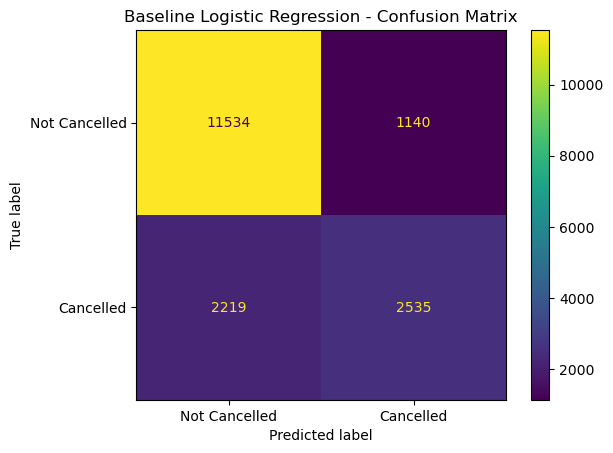

In [95]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Cancelled', 'Cancelled']
).plot()

plt.title("Baseline Logistic Regression - Confusion Matrix")
plt.show()

In [96]:
from imblearn.over_sampling import SMOTE

print("Original training distribution:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)

X_train_transformed = model_pipeline.named_steps['preprocessor'].fit_transform(X_train)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_transformed,
    y_train
)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Original training distribution:
is_canceled
0    50697
1    19013
Name: count, dtype: int64

After SMOTE:
is_canceled
0    50697
1    50697
Name: count, dtype: int64


In [97]:
smote_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

smote_model.fit(X_train_smote, y_train_smote)

print("SMOTE Logistic Regression model fitted successfully.")

SMOTE Logistic Regression model fitted successfully.


In [98]:
y_pred_smote = smote_model.predict(X_test_transformed)

accuracy_smote = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote)

print("SMOTE Logistic Regression Results")
print("---------------------------------")
print(f"Accuracy : {accuracy_smote:.4f}")
print(f"Precision: {precision_smote:.4f}")
print(f"Recall   : {recall_smote:.4f}")
print(f"F1-score : {f1_smote:.4f}")

SMOTE Logistic Regression Results
---------------------------------
Accuracy : 0.7770
Precision: 0.5630
Recall   : 0.8162
F1-score : 0.6663


In [99]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Baseline': [accuracy, precision, recall, f1],
    'SMOTE': [accuracy_smote, precision_smote, recall_smote, f1_smote]
})

comparison['Difference'] = comparison['SMOTE'] - comparison['Baseline']

print(comparison.round(4))

      Metric  Baseline   SMOTE  Difference
0   Accuracy    0.8073  0.7770     -0.0302
1  Precision    0.6898  0.5630     -0.1268
2     Recall    0.5332  0.8162      0.2829
3   F1-score    0.6015  0.6663      0.0648


In [100]:
skewness = X_train[numeric_features].skew().sort_values(ascending=False)

print("Numerical feature skewness:")
print(skewness.round(3))

Numerical feature skewness:
previous_cancellations            33.026
babies                            23.055
adults                            21.740
previous_bookings_not_canceled    20.538
days_in_waiting_list              20.097
adr                               14.487
total_guests                      11.395
booking_changes                    5.344
is_repeated_guest                  4.737
children                           3.483
required_car_parking_spaces        3.324
total_stay_nights                  3.055
stays_in_week_nights               2.677
lead_time                          1.443
stays_in_weekend_nights            1.393
total_of_special_requests          1.082
arrival_date_week_number           0.019
arrival_date_day_of_month         -0.004
arrival_date_year                 -0.297
dtype: float64


In [101]:
highly_skewed = skewness[abs(skewness) > 1]

print("Features with |skewness| > 1:")
print(highly_skewed.round(3))

print("\nNumber of highly skewed features:", len(highly_skewed))

Features with |skewness| > 1:
previous_cancellations            33.026
babies                            23.055
adults                            21.740
previous_bookings_not_canceled    20.538
days_in_waiting_list              20.097
adr                               14.487
total_guests                      11.395
booking_changes                    5.344
is_repeated_guest                  4.737
children                           3.483
required_car_parking_spaces        3.324
total_stay_nights                  3.055
stays_in_week_nights               2.677
lead_time                          1.443
stays_in_weekend_nights            1.393
total_of_special_requests          1.082
dtype: float64

Number of highly skewed features: 16


In [102]:
from sklearn.preprocessing import MinMaxScaler

standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

X_train_numeric = X_train[numeric_features].copy()

X_train_standardised = standard_scaler.fit_transform(
    X_train_numeric.fillna(X_train_numeric.median())
)

X_train_normalised = minmax_scaler.fit_transform(
    X_train_numeric.fillna(X_train_numeric.median())
)

print("Original numerical data:")
print(X_train_numeric.describe().loc[['min', 'max']].round(2))

print("\nStandardised data - approximate range:")
print(
    pd.DataFrame(X_train_standardised, columns=numeric_features)
    .describe()
    .loc[['min', 'max']]
    .round(2)
)

print("\nMin-Max normalised data - range:")
print(
    pd.DataFrame(X_train_normalised, columns=numeric_features)
    .describe()
    .loc[['min', 'max']]
    .round(2)
)

Original numerical data:
     lead_time  arrival_date_year  arrival_date_week_number  \
min        0.0             2015.0                       1.0   
max      737.0             2017.0                      53.0   

     arrival_date_day_of_month  stays_in_weekend_nights  stays_in_week_nights  \
min                        1.0                      0.0                   0.0   
max                       31.0                     19.0                  50.0   

     adults  children  babies  is_repeated_guest  previous_cancellations  \
min     0.0       0.0     0.0                0.0                     0.0   
max    55.0      10.0    10.0                1.0                    26.0   

     previous_bookings_not_canceled  booking_changes  days_in_waiting_list  \
min                             0.0              0.0                   0.0   
max                            72.0             20.0                 391.0   

         adr  required_car_parking_spaces  total_of_special_requests  \
min  

In [103]:
import numpy as np

skewed_features = [
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests',
    'total_stay_nights',
    'total_guests'
]

log_skewness = {}

for feature in skewed_features:
    values = X_train[feature].fillna(X_train[feature].median())
    transformed = np.log1p(values)
    log_skewness[feature] = transformed.skew()

log_skewness = pd.Series(log_skewness).sort_values(ascending=False)

print("Skewness after log1p transformation:")
print(log_skewness.round(3))

Skewness after log1p transformation:
days_in_waiting_list              10.797
previous_cancellations            10.457
babies                            10.238
previous_bookings_not_canceled     6.974
children                           3.049
required_car_parking_spaces        3.022
booking_changes                    2.249
total_of_special_requests          0.441
total_stay_nights                  0.216
stays_in_weekend_nights            0.095
total_guests                      -0.034
stays_in_week_nights              -0.151
lead_time                         -0.712
adr                               -0.746
adults                            -0.970
dtype: float64


In [104]:
skewness_comparison = pd.DataFrame({
    'Original_Skewness': skewness[skewed_features],
    'Log1p_Skewness': log_skewness
})

skewness_comparison['Absolute_Original'] = (
    skewness_comparison['Original_Skewness'].abs()
)

skewness_comparison['Absolute_Log1p'] = (
    skewness_comparison['Log1p_Skewness'].abs()
)

print(
    skewness_comparison[
        ['Original_Skewness', 'Log1p_Skewness']
    ].round(3)
)

                                Original_Skewness  Log1p_Skewness
adr                                        14.487          -0.746
adults                                     21.740          -0.970
babies                                     23.055          10.238
booking_changes                             5.344           2.249
children                                    3.483           3.049
days_in_waiting_list                       20.097          10.797
lead_time                                   1.443          -0.712
previous_bookings_not_canceled             20.538           6.974
previous_cancellations                     33.026          10.457
required_car_parking_spaces                 3.324           3.022
stays_in_week_nights                        2.677          -0.151
stays_in_weekend_nights                     1.393           0.095
total_guests                               11.395          -0.034
total_of_special_requests                   1.082           0.441
total_stay

In [106]:
from sklearn.preprocessing import PowerTransformer

power_features = [
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'booking_changes',
    'days_in_waiting_list',
    'adr',
    'total_stay_nights'
]

X_power = X_train[power_features].copy()

X_power = X_power.fillna(
    X_power.median()
)

power_transformer = PowerTransformer(
    method='yeo-johnson',
    standardize=True
)

X_train_power = power_transformer.fit_transform(X_power)

power_skewness = pd.DataFrame(
    X_train_power,
    columns=power_features
).skew()

print("Skewness after Yeo-Johnson transformation:")
print(power_skewness.round(3))

Skewness after Yeo-Johnson transformation:
lead_time                  -0.138
stays_in_weekend_nights     0.031
stays_in_week_nights        0.003
booking_changes             1.645
days_in_waiting_list       10.007
adr                         0.062
total_stay_nights           0.005
dtype: float64


In [107]:
X_train_transformed = model_pipeline.named_steps['preprocessor'].fit_transform(X_train)

print("Transformed training data shape:", X_train_transformed.shape)

Transformed training data shape: (69710, 574)


In [108]:
from sklearn.decomposition import PCA

pca = PCA()

X_train_dense = X_train_transformed.toarray()

X_train_pca = pca.fit_transform(X_train_dense)

explained_variance = np.cumsum(
    pca.explained_variance_ratio_
)

components_95 = np.argmax(
    explained_variance >= 0.95
) + 1

print("Original transformed features:", X_train_dense.shape[1])
print("PCA components for 95% variance:", components_95)
print(
    "Explained variance at that point:",
    round(explained_variance[components_95 - 1], 4)
)

Original transformed features: 574
PCA components for 95% variance: 41
Explained variance at that point: 0.9521


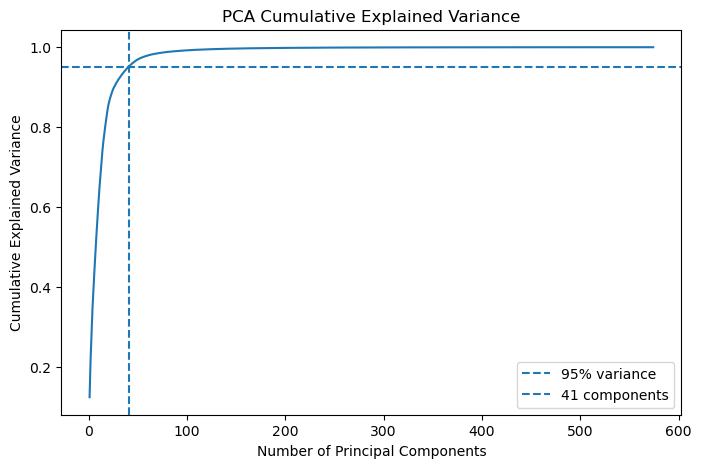

In [109]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance
)

plt.axhline(
    y=0.95,
    linestyle='--',
    label='95% variance'
)

plt.axvline(
    x=components_95,
    linestyle='--',
    label=f'{components_95} components'
)

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.legend()
plt.show()

In [110]:
print("Final modelling dataset shape:", df_model.shape)

print("\nTarget:")
print("is_canceled")

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nTotal numerical features:", len(numeric_features))
print("Total categorical features:", len(categorical_features))

Final modelling dataset shape: (87138, 32)

Target:
is_canceled

Numerical features:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_stay_nights', 'total_guests']

Categorical features:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'agent', 'customer_type']

Total numerical features: 19
Total categorical features: 11


In [111]:
remaining_missing = X.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

print("Remaining missing values before pipeline:")
print(remaining_missing)

if len(remaining_missing) == 0:
    print("\nNo remaining missing values requiring preprocessing.")

Remaining missing values before pipeline:
adr    1779
dtype: int64


In [112]:
final_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]),
            numeric_features
        ),
        (
            'cat',
            Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))
            ]),
            categorical_features
        )
    ]
)

final_pipeline = Pipeline(steps=[
    ('preprocessor', final_preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

print("Final preprocessing and modelling pipeline created successfully.")
print("\nWorkflow:")
print("1. Numerical imputation → Standardisation")
print("2. Categorical imputation → One-hot encoding")
print("3. Logistic Regression")

Final preprocessing and modelling pipeline created successfully.

Workflow:
1. Numerical imputation → Standardisation
2. Categorical imputation → One-hot encoding
3. Logistic Regression


In [113]:
final_pipeline.fit(X_train, y_train)

y_pred_final = final_pipeline.predict(X_test)

final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)

print("Final Preprocessing Pipeline Results")
print("------------------------------------")
print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1-score : {final_f1:.4f}")

Final Preprocessing Pipeline Results
------------------------------------
Accuracy : 0.8073
Precision: 0.6898
Recall   : 0.5332
F1-score : 0.6015


In [114]:
final_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Baseline': [accuracy, precision, recall, f1],
    'SMOTE': [accuracy_smote, precision_smote, recall_smote, f1_smote],
    'Final Pipeline': [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1
    ]
})

print(final_comparison.round(4))

      Metric  Baseline   SMOTE  Final Pipeline
0   Accuracy    0.8073  0.7770          0.8073
1  Precision    0.6898  0.5630          0.6898
2     Recall    0.5332  0.8162          0.5332
3   F1-score    0.6015  0.6663          0.6015


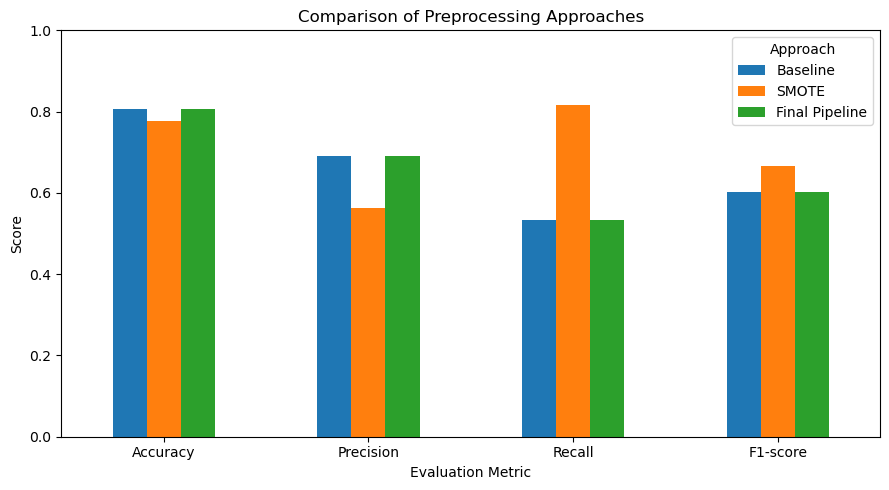

In [115]:
final_comparison_plot = final_comparison.set_index('Metric')

ax = final_comparison_plot.plot(
    kind='bar',
    figsize=(9, 5)
)

ax.set_title("Comparison of Preprocessing Approaches")
ax.set_ylabel("Score")
ax.set_xlabel("Evaluation Metric")
ax.set_ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(title="Approach")
plt.tight_layout()
plt.show()

In [116]:
print("FINAL DATASET CHECK")
print("===================")

print("Dataset shape:", df_model.shape)

print("\nMissing values:")
print(df_model.isnull().sum().sum())

print("\nDuplicate rows:")
print(df_model.duplicated().sum())

print("\nTarget distribution:")
print(df_model['is_canceled'].value_counts())

print("\nTarget percentages:")
print((df_model['is_canceled'].value_counts(normalize=True) * 100).round(2))

print("\nLeakage columns remaining:")
print([col for col in ['reservation_status', 'reservation_status_date']
       if col in df_model.columns])

FINAL DATASET CHECK
Dataset shape: (87138, 32)

Missing values:
1779

Duplicate rows:
5

Target distribution:
is_canceled
0    63371
1    23767
Name: count, dtype: int64

Target percentages:
is_canceled
0    72.72
1    27.28
Name: proportion, dtype: float64

Leakage columns remaining:
[]


In [117]:
print("Remaining missing values by column:")
print(df_model.isnull().sum()[df_model.isnull().sum() > 0])

Remaining missing values by column:
adr    1779
dtype: int64


In [118]:
duplicate_count = df_model.duplicated().sum()

print("Remaining duplicate rows:", duplicate_count)

if duplicate_count > 0:
    print("\nDuplicate rows:")
    display(df_model[df_model.duplicated(keep=False)].sort_values(
        by=df_model.columns.tolist()
    ).head(20))

Remaining duplicate rows: 5

Duplicate rows:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,has_company,total_stay_nights,total_guests
14282,Resort Hotel,0,0,2015,November,47,18,0,1,1,...,No Deposit,Unknown,0,Transient,38.0,0,0,1,1,1.0
14283,Resort Hotel,0,0,2015,November,47,18,0,1,1,...,No Deposit,Unknown,0,Transient,38.0,0,0,1,1,1.0
27808,Resort Hotel,0,0,2017,February,8,21,0,1,1,...,No Deposit,Unknown,0,Transient,35.0,0,0,1,1,1.0
27817,Resort Hotel,0,0,2017,February,8,21,0,1,1,...,No Deposit,Unknown,0,Transient,35.0,0,0,1,1,1.0
2596,Resort Hotel,0,1,2015,November,45,4,0,1,1,...,No Deposit,Unknown,0,Transient,35.0,0,0,1,1,1.0
14050,Resort Hotel,0,1,2015,November,45,4,0,1,1,...,No Deposit,Unknown,0,Transient,35.0,0,0,1,1,1.0
25815,Resort Hotel,0,2,2016,December,51,14,0,1,1,...,No Deposit,Unknown,0,Transient,30.0,0,0,1,1,1.0
25827,Resort Hotel,0,2,2016,December,51,14,0,1,1,...,No Deposit,Unknown,0,Transient,30.0,0,0,1,1,1.0
9383,Resort Hotel,1,8,2017,July,27,5,0,1,1,...,No Deposit,Unknown,0,Transient,135.0,0,0,1,1,1.0
9384,Resort Hotel,1,8,2017,July,27,5,0,1,1,...,No Deposit,Unknown,0,Transient,135.0,0,0,1,1,1.0


In [119]:
adr_median = df_model['adr'].median()

print("ADR median:", adr_median)
print("Missing ADR before imputation:", df_model['adr'].isna().sum())

df_model['adr'] = df_model['adr'].fillna(adr_median)

print("Missing ADR after imputation:", df_model['adr'].isna().sum())

ADR median: 99.0
Missing ADR before imputation: 1779
Missing ADR after imputation: 0


In [120]:
duplicates_before = df_model.duplicated().sum()

df_model = df_model.drop_duplicates().reset_index(drop=True)

duplicates_after = df_model.duplicated().sum()

print("Duplicates before final removal:", duplicates_before)
print("Duplicates after final removal:", duplicates_after)
print("Final dataset shape:", df_model.shape)

Duplicates before final removal: 5
Duplicates after final removal: 0
Final dataset shape: (87133, 32)


In [121]:
print("FINAL VALIDATION")
print("================")

print("Dataset shape:", df_model.shape)

print("\nTotal missing values:", df_model.isnull().sum().sum())

print("Total duplicate rows:", df_model.duplicated().sum())

print("\nTarget distribution:")
print(df_model['is_canceled'].value_counts())

print("\nLeakage columns:")
print([
    col for col in ['reservation_status', 'reservation_status_date']
    if col in df_model.columns
])

FINAL VALIDATION
Dataset shape: (87133, 32)

Total missing values: 0
Total duplicate rows: 0

Target distribution:
is_canceled
0    63367
1    23766
Name: count, dtype: int64

Leakage columns:
[]
